# Synthetic Agricultural Dataset Generator
**Project:** Optimal Resource Allocation in Precision Agriculture  
**Task:** Multi-output regression — predict optimal water & fertilizer allocation  
**Dataset 1:** Synthetic (rule-based with controlled noise)  
**Dataset 2:** Generative AI-based (same structure, augmented via prompting)

In [6]:
# ── Cell 1 : Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)          # reproducibility
N = 2000                    # number of samples
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [7]:
# ── Cell 2 : Categorical feature definitions ──────────────────────────────────

SOIL_TYPES     = ['Sandy', 'Clay', 'Loam', 'Silty']
CROP_TYPES     = ['Wheat', 'Corn', 'Tomato', 'Potato', 'Sunflower']
GROWTH_STAGES  = ['Seedling', 'Vegetative', 'Flowering', 'Fruiting', 'Harvest']

# Water retention coefficient per soil type (higher → soil holds more water)
SOIL_WATER_COEFF = {'Sandy': 0.3, 'Clay': 0.9, 'Loam': 0.6, 'Silty': 0.75}

# Base water demand per crop (L / ha / day)
CROP_WATER_BASE  = {'Wheat': 400, 'Corn': 550, 'Tomato': 650, 'Potato': 500, 'Sunflower': 480}

# Base nitrogen demand per crop (kg / ha)
CROP_N_BASE      = {'Wheat': 120, 'Corn': 160, 'Tomato': 100, 'Potato': 130, 'Sunflower': 90}

# Base phosphorus demand per crop (kg / ha)
CROP_P_BASE      = {'Wheat': 60,  'Corn': 80,  'Tomato': 50,  'Potato': 70,  'Sunflower': 45}

# Growth stage multiplier on water demand
STAGE_WATER_MULT = {'Seedling': 0.6, 'Vegetative': 0.85, 'Flowering': 1.2, 'Fruiting': 1.0, 'Harvest': 0.5}

print("Domain constants defined.")

Domain constants defined.


In [8]:
# ── Cell 3 : Generate categorical & continuous input features ─────────────────

soil_type    = np.random.choice(SOIL_TYPES,    N)
crop_type    = np.random.choice(CROP_TYPES,    N)
growth_stage = np.random.choice(GROWTH_STAGES, N)

temperature      = np.random.uniform(10, 42, N)          # °C
humidity         = np.random.uniform(20, 90, N)          # %
rainfall         = np.random.uniform(0, 120, N)          # mm / week
soil_moisture    = np.random.uniform(10, 70, N)          # %
soil_pH          = np.round(np.random.uniform(5.0, 8.5, N), 1)  # pH
nitrogen_level   = np.random.uniform(10, 200, N)         # mg/kg in soil
phosphorus_level = np.random.uniform(5, 100, N)          # mg/kg in soil
potassium_level  = np.random.uniform(50, 400, N)         # mg/kg in soil
field_area       = np.round(np.random.uniform(0.5, 50, N), 1)   # hectares

print(f"Generated {N} samples with 12 input features.")

Generated 2000 samples with 12 input features.


In [9]:
# ── Cell 4 : Compute realistic target variables ───────────────────────────────
#
# TARGET 1 — water_allocation (L / ha)
#   Logic: base demand adjusted by temperature, soil retention, moisture,
#          rainfall, growth stage, and humidity.
#
# TARGET 2 — fertilizer_N (kg / ha)  (Nitrogen)
#   Logic: base N need reduced by existing soil nitrogen and soil pH effect.
#
# TARGET 3 — fertilizer_P (kg / ha)  (Phosphorus)
#   Logic: base P need reduced by existing phosphorus and pH solubility effect.
# ─────────────────────────────────────────────────────────────────────────────

water_alloc = np.zeros(N)
fert_N      = np.zeros(N)
fert_P      = np.zeros(N)

for i in range(N):
    s  = soil_type[i]
    c  = crop_type[i]
    g  = growth_stage[i]

    # ── Water allocation ──────────────────────────────────────────────────────
    heat_factor     = 1 + (temperature[i] - 25) * 0.02      # more heat → more water
    humidity_factor = 1 - (humidity[i] - 55) * 0.003        # high humidity → less water
    rain_factor     = max(0.3, 1 - rainfall[i] / 150)       # rain reduces irrigation need
    moisture_factor = max(0.2, 1 - soil_moisture[i] / 80)   # wet soil → less water needed
    soil_factor     = 1 - SOIL_WATER_COEFF[s] * 0.3         # clay retains water → less supply

    water_alloc[i] = (
        CROP_WATER_BASE[c]
        * STAGE_WATER_MULT[g]
        * heat_factor
        * humidity_factor
        * rain_factor
        * moisture_factor
        * soil_factor
    )

    # ── Nitrogen fertilizer ───────────────────────────────────────────────────
    n_deficiency = max(0, 1 - nitrogen_level[i] / 200)      # less N in soil → more fertilizer
    ph_n_factor  = 1 - abs(soil_pH[i] - 6.5) * 0.05        # optimal pH 6.5 for N uptake

    fert_N[i] = CROP_N_BASE[c] * n_deficiency * ph_n_factor

    # ── Phosphorus fertilizer ─────────────────────────────────────────────────
    p_deficiency = max(0, 1 - phosphorus_level[i] / 100)    # less P in soil → more fertilizer
    ph_p_factor  = 1 - abs(soil_pH[i] - 6.8) * 0.04        # optimal pH 6.8 for P solubility

    fert_P[i] = CROP_P_BASE[c] * p_deficiency * ph_p_factor

print("Target variables computed.")

Target variables computed.


In [10]:
# ── Cell 5 : Add realistic Gaussian noise to targets ─────────────────────────
#   Simulates measurement uncertainty and unmodelled environmental factors.

water_alloc += np.random.normal(0, 20, N)   # ± ~20 L/ha noise
fert_N      += np.random.normal(0, 3,  N)   # ± ~3 kg/ha noise
fert_P      += np.random.normal(0, 2,  N)   # ± ~2 kg/ha noise

# Clip to realistic positive bounds
water_alloc = np.clip(water_alloc, 30, 900)
fert_N      = np.clip(fert_N,       0, 200)
fert_P      = np.clip(fert_P,       0, 100)

print("Gaussian noise added and values clipped to realistic bounds.")

Gaussian noise added and values clipped to realistic bounds.


In [11]:
# ── Cell 6 : Assemble the DataFrame ──────────────────────────────────────────

df = pd.DataFrame({
    # — Categorical features —
    'soil_type'         : soil_type,
    'crop_type'         : crop_type,
    'growth_stage'      : growth_stage,
    # — Continuous features —
    'temperature_C'     : np.round(temperature,      1),
    'humidity_pct'      : np.round(humidity,          1),
    'rainfall_mm'       : np.round(rainfall,          1),
    'soil_moisture_pct' : np.round(soil_moisture,     1),
    'soil_pH'           : soil_pH,
    'nitrogen_mgkg'     : np.round(nitrogen_level,    1),
    'phosphorus_mgkg'   : np.round(phosphorus_level,  1),
    'potassium_mgkg'    : np.round(potassium_level,   1),
    'field_area_ha'     : field_area,
    # — Target variables —
    'water_allocation_L_ha'  : np.round(water_alloc, 1),
    'fertilizer_N_kg_ha'     : np.round(fert_N,      2),
    'fertilizer_P_kg_ha'     : np.round(fert_P,      2),
})

print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (2000, 15)


,soil_type,crop_type,growth_stage,temperature_C,humidity_pct,rainfall_mm,soil_moisture_pct,soil_pH,nitrogen_mgkg,phosphorus_mgkg,potassium_mgkg,field_area_ha,water_allocation_L_ha,fertilizer_N_kg_ha,fertilizer_P_kg_ha
0,Loam,Potato,Fruiting,24.2,34.7,69.3,22.1,6.0,147.6,65.0,284.7,40.0,137.6,36.84,24.27
1,Silty,Tomato,Fruiting,29.7,25.1,7.9,24.1,7.4,117.4,77.6,207.2,47.7,415.6,41.07,8.93
2,Sandy,Sunflower,Fruiting,37.2,69.2,23.0,41.3,6.1,99.0,79.0,361.7,3.5,202.9,41.48,12.05
3,Loam,Wheat,Vegetative,16.3,48.2,48.9,20.3,7.8,178.8,78.2,267.9,19.9,121.9,11.49,11.81
4,Loam,Sunflower,Vegetative,14.0,84.4,112.4,28.3,5.5,155.7,26.5,396.6,24.6,30.0,14.00,31.15


In [12]:
# ── Cell 7 : Inject missing values (~5% random) ──────────────────────────────
#   Simulates real-world sensor failures or incomplete records.
#   Only inject into continuous numerical columns (not targets).

MISSING_RATE = 0.05
cols_with_missing = ['rainfall_mm', 'soil_moisture_pct', 'humidity_pct',
                     'nitrogen_mgkg', 'phosphorus_mgkg']

for col in cols_with_missing:
    mask = np.random.rand(N) < MISSING_RATE
    df.loc[mask, col] = np.nan

print(f"Missing values injected (~{MISSING_RATE*100:.0f}% per selected column).")
print(df[cols_with_missing].isnull().sum())

Missing values injected (~5% per selected column).
rainfall_mm           94
soil_moisture_pct     96
humidity_pct          96
nitrogen_mgkg        101
phosphorus_mgkg      121
dtype: int64


In [13]:
# ── Cell 8 : Inject a few duplicate rows (to practice cleaning) ───────────────

dup_indices = np.random.choice(N, size=40, replace=False)
df_duplicates = df.iloc[dup_indices].copy()
df = pd.concat([df, df_duplicates], ignore_index=True)

print(f"DataFrame shape after adding duplicates: {df.shape}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

DataFrame shape after adding duplicates: (2040, 15)
Number of duplicate rows: 40


In [14]:
# ── Cell 9 : Inject a few outliers (to practice detection) ───────────────────

outlier_idx = np.random.choice(len(df), size=15, replace=False)
df.loc[outlier_idx, 'temperature_C']    = np.random.uniform(55, 70, 15)   # unrealistic temps
df.loc[outlier_idx, 'water_allocation_L_ha'] = np.random.uniform(1200, 2000, 15)  # extreme values

print(f"15 outlier rows injected.")
df.describe().T[['min', 'max', 'mean', 'std']]

15 outlier rows injected.


,min,max,mean,std
temperature_C,10.0,68.821210,26.131695,9.708276
humidity_pct,20.0,89.900000,54.208441,19.977789
rainfall_mm,0.0,119.900000,59.235200,33.805767
soil_moisture_pct,10.0,70.000000,40.528549,17.363759
soil_pH,5.0,8.500000,6.719559,1.020801
nitrogen_mgkg,10.1,200.000000,105.568386,55.492069
phosphorus_mgkg,5.0,99.900000,53.772370,26.981483
potassium_mgkg,50.2,400.000000,227.990686,100.990155
field_area_ha,0.5,50.000000,25.785833,14.422717
water_allocation_L_ha,30.0,1990.495599,119.333287,143.997155


In [15]:
# ── Cell 10 : Quick statistical overview ─────────────────────────────────────

print("=== Dataset Info ===")
print(f"Total rows     : {len(df)}")
print(f"Total columns  : {df.shape[1]}")
print(f"Duplicates     : {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
print("=== Target Variable Ranges ===")
for col in ['water_allocation_L_ha', 'fertilizer_N_kg_ha', 'fertilizer_P_kg_ha']:
    print(f"  {col:<30}  min={df[col].min():.1f}  max={df[col].max():.1f}  mean={df[col].mean():.1f}")

=== Dataset Info ===
Total rows     : 2040
Total columns  : 15
Duplicates     : 40
Missing values : 517

=== Target Variable Ranges ===
  water_allocation_L_ha           min=30.0  max=1990.5  mean=119.3
  fertilizer_N_kg_ha              min=0.0  max=151.4  mean=54.0
  fertilizer_P_kg_ha              min=0.0  max=75.7  mean=27.3


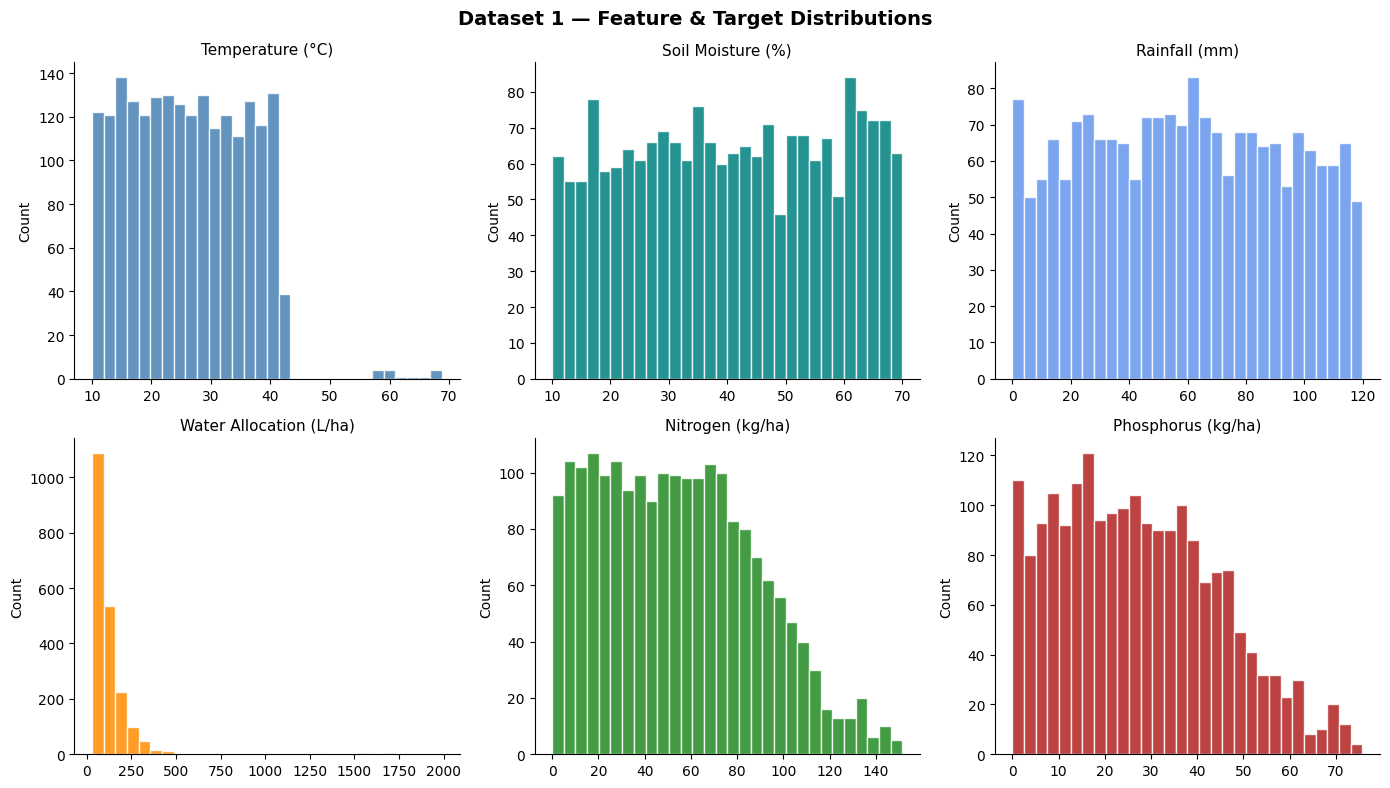

In [16]:
# ── Cell 11 : Visualise distributions of key features ───────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Dataset 1 — Feature & Target Distributions', fontsize=14, fontweight='bold')

plot_cols = [
    ('temperature_C',        'Temperature (°C)',       'steelblue'),
    ('soil_moisture_pct',    'Soil Moisture (%)',      'teal'),
    ('rainfall_mm',          'Rainfall (mm)',          'cornflowerblue'),
    ('water_allocation_L_ha','Water Allocation (L/ha)','darkorange'),
    ('fertilizer_N_kg_ha',   'Nitrogen (kg/ha)',       'forestgreen'),
    ('fertilizer_P_kg_ha',   'Phosphorus (kg/ha)',     'firebrick'),
]

for ax, (col, label, color) in zip(axes.flat, plot_cols):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('dataset1_distributions.png', dpi=120)
plt.show()

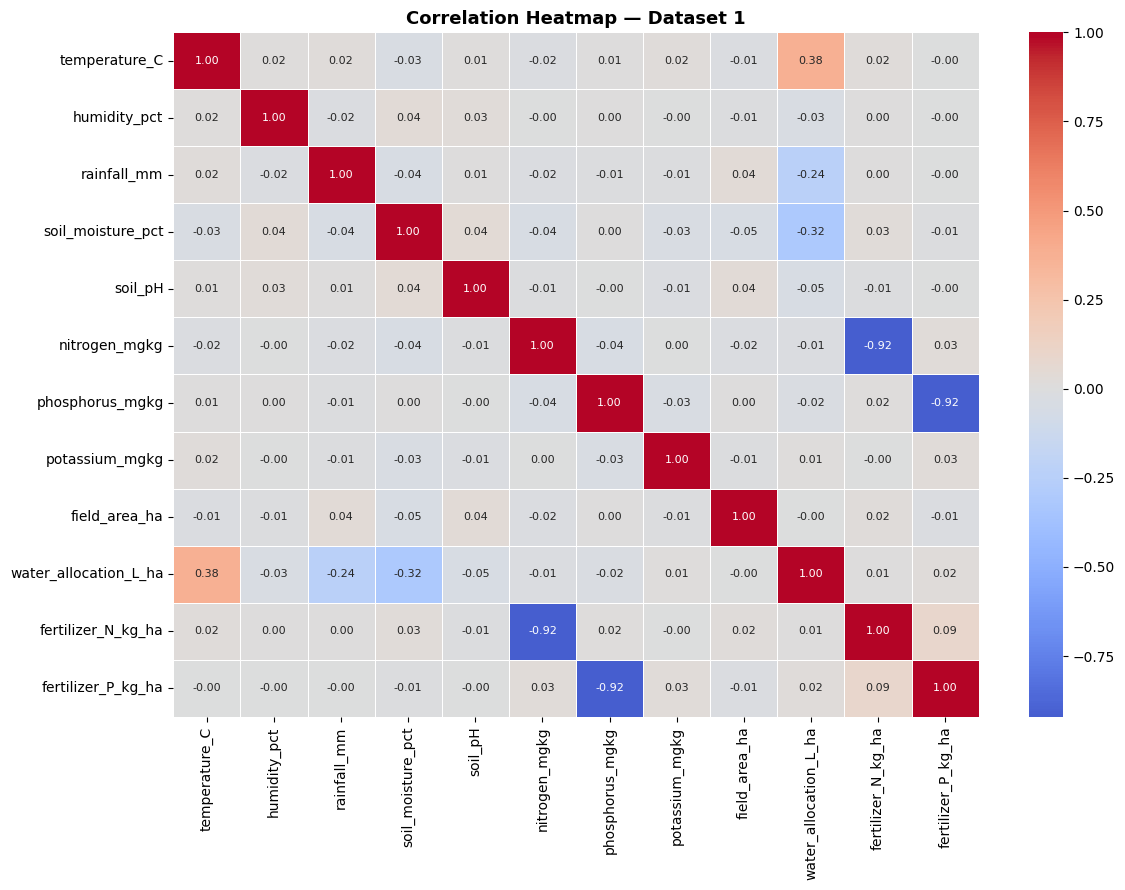

In [17]:
# ── Cell 12 : Correlation heatmap (numeric features only) ────────────────────

numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix  = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Correlation Heatmap — Dataset 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset1_correlation.png', dpi=120)
plt.show()

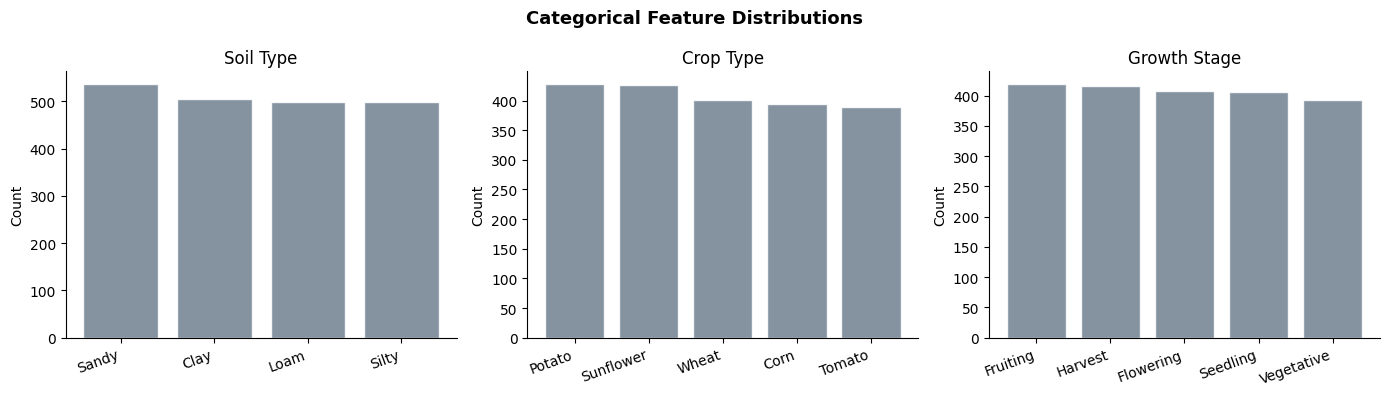

In [18]:
# ── Cell 13 : Countplots for categorical features ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['soil_type', 'crop_type', 'growth_stage']):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='slategray', edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('dataset1_categorical.png', dpi=120)
plt.show()

In [19]:
# ── Cell 14 : Export Dataset 1 to CSV ────────────────────────────────────────

os.makedirs('datasets', exist_ok=True)
df.to_csv('datasets/dataset1_agriculture_raw.csv', index=False)

print("Dataset 1 saved to: datasets/dataset1_agriculture_raw.csv")
print(f"Shape  : {df.shape}")
print(f"Size   : {os.path.getsize('datasets/dataset1_agriculture_raw.csv') / 1024:.1f} KB")

Dataset 1 saved to: datasets/dataset1_agriculture_raw.csv
Shape  : (2040, 15)
Size   : 168.3 KB


In [20]:
# ── Cell 15 : Generate Dataset 2 (Generative AI simulation) ──────────────────
#
# In a real project you would prompt a chatbot (ChatGPT / Claude) with a
# description of your schema and collect the output as a CSV.
#
# Here we SIMULATE what such a generated dataset might look like by using
# different random distributions (different means / variances), simulating
# a slightly different "agricultural region" generated by the AI.
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(99)          # different seed → different distribution
N2 = 500                    # AI-generated datasets are typically smaller

soil_type2    = np.random.choice(SOIL_TYPES,    N2, p=[0.2, 0.3, 0.35, 0.15])  # biased toward Clay/Loam
crop_type2    = np.random.choice(CROP_TYPES,    N2, p=[0.15, 0.35, 0.2, 0.15, 0.15])  # Corn-heavy
growth_stage2 = np.random.choice(GROWTH_STAGES, N2)

temperature2      = np.random.normal(28, 6, N2).clip(12, 45)    # warmer region
humidity2         = np.random.normal(60, 15, N2).clip(20, 90)
rainfall2         = np.random.exponential(40, N2).clip(0, 120)  # more skewed (arid)
soil_moisture2    = np.random.normal(35, 12, N2).clip(10, 70)
soil_pH2          = np.round(np.random.normal(6.8, 0.7, N2).clip(5.0, 8.5), 1)
nitrogen_level2   = np.random.normal(80, 40, N2).clip(10, 200)
phosphorus_level2 = np.random.normal(40, 20, N2).clip(5, 100)
potassium_level2  = np.random.normal(180, 70, N2).clip(50, 400)
field_area2       = np.round(np.random.lognormal(2.5, 0.8, N2).clip(0.5, 50), 1)

# Recompute targets for Dataset 2
water2, n2, p2 = np.zeros(N2), np.zeros(N2), np.zeros(N2)
for i in range(N2):
    s, c, g = soil_type2[i], crop_type2[i], growth_stage2[i]
    hf = 1 + (temperature2[i] - 25) * 0.02
    huf = 1 - (humidity2[i] - 55) * 0.003
    rf = max(0.3, 1 - rainfall2[i] / 150)
    mf = max(0.2, 1 - soil_moisture2[i] / 80)
    sf = 1 - SOIL_WATER_COEFF[s] * 0.3
    water2[i] = CROP_WATER_BASE[c] * STAGE_WATER_MULT[g] * hf * huf * rf * mf * sf
    n2[i]     = CROP_N_BASE[c]  * max(0, 1 - nitrogen_level2[i] / 200)   * (1 - abs(soil_pH2[i] - 6.5) * 0.05)
    p2[i]     = CROP_P_BASE[c]  * max(0, 1 - phosphorus_level2[i] / 100) * (1 - abs(soil_pH2[i] - 6.8) * 0.04)

water2 = np.clip(water2 + np.random.normal(0, 25, N2), 30, 900)
n2     = np.clip(n2     + np.random.normal(0, 4,  N2),  0, 200)
p2     = np.clip(p2     + np.random.normal(0, 2,  N2),  0, 100)

df2 = pd.DataFrame({
    'soil_type'              : soil_type2,
    'crop_type'              : crop_type2,
    'growth_stage'           : growth_stage2,
    'temperature_C'          : np.round(temperature2,      1),
    'humidity_pct'           : np.round(humidity2,          1),
    'rainfall_mm'            : np.round(rainfall2,          1),
    'soil_moisture_pct'      : np.round(soil_moisture2,     1),
    'soil_pH'                : soil_pH2,
    'nitrogen_mgkg'          : np.round(nitrogen_level2,    1),
    'phosphorus_mgkg'        : np.round(phosphorus_level2,  1),
    'potassium_mgkg'         : np.round(potassium_level2,   1),
    'field_area_ha'          : field_area2,
    'water_allocation_L_ha'  : np.round(water2, 1),
    'fertilizer_N_kg_ha'     : np.round(n2, 2),
    'fertilizer_P_kg_ha'     : np.round(p2, 2),
    'source'                 : 'generative_AI',          # mark the origin
})

df2.to_csv('datasets/dataset2_agriculture_genAI.csv', index=False)
print(f"Dataset 2 (GenAI) saved — Shape: {df2.shape}")
df2.head()

Dataset 2 (GenAI) saved — Shape: (500, 16)


,soil_type,crop_type,growth_stage,temperature_C,humidity_pct,rainfall_mm,soil_moisture_pct,soil_pH,nitrogen_mgkg,phosphorus_mgkg,potassium_mgkg,field_area_ha,water_allocation_L_ha,fertilizer_N_kg_ha,fertilizer_P_kg_ha,source
0,Loam,Tomato,Harvest,33.2,62.4,38.5,47.7,6.1,73.3,30.2,139.0,14.9,122.6,57.97,35.45,generative_AI
1,Clay,Tomato,Flowering,24.5,41.3,12.2,36.0,6.5,82.2,40.6,295.0,36.6,288.9,55.42,31.07,generative_AI
2,Loam,Sunflower,Seedling,30.4,89.5,67.0,26.3,5.7,36.8,60.6,115.7,8.7,35.7,73.07,16.30,generative_AI
3,Sandy,Corn,Harvest,22.2,72.2,54.7,36.9,7.6,51.2,62.3,200.8,5.8,53.3,117.46,27.87,generative_AI
4,Loam,Corn,Vegetative,37.7,75.0,57.9,37.6,7.4,143.5,36.6,250.3,5.1,119.4,43.94,48.17,generative_AI


---
## Summary
| | Dataset 1 | Dataset 2 (GenAI) |
|---|---|---|
| Rows | 2040 (incl. 40 duplicates) | 500 |
| Features | 12 | 12 + `source` |
| Targets | 3 | 3 |
| Missing values | ~5% on 5 columns | None |
| Outliers | 15 rows | None |
| Split method | Train / Val / Test | Cross-validation (k-Fold) |

**Next steps:** Load → Clean → Feature Engineering → PCA/LDA → Model training